!python -m pip install --upgrade pip

!pip install git+https://github.com/facebookresearch/segment-anything.git

## Model semantic segmentation
---

In [1]:
#external
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

#visualization
import cv2

#model
from src.segment_anything_model import SAMModel
import supervision as sv

#utils
from src.utils.dataset import load_foodseg103_splits

In [2]:
sam_model = SAMModel(
    model_path="src/model/sam_vit_h_4b8939.pth",
    model_type="vit_h"
)

In [3]:
image_dataset = load_foodseg103_splits()["test"]

In [4]:
test_image_idx = random.randint(0, len(image_dataset) - 1)
test_image = np.array(image_dataset[test_image_idx]["image"])
#image_rgb = cv2.cvtColor(test_image, cv2.COLOR_BGR2RGB)
image_rgb = cv2.resize(test_image, (256, 256), interpolation=cv2.INTER_LINEAR)
image_rgb.shape

(256, 256, 3)

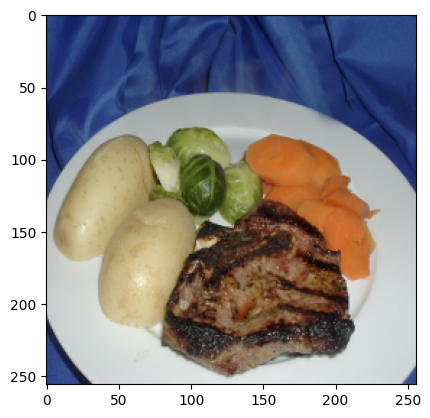

In [5]:
plt.imshow(image_rgb)
plt.show()

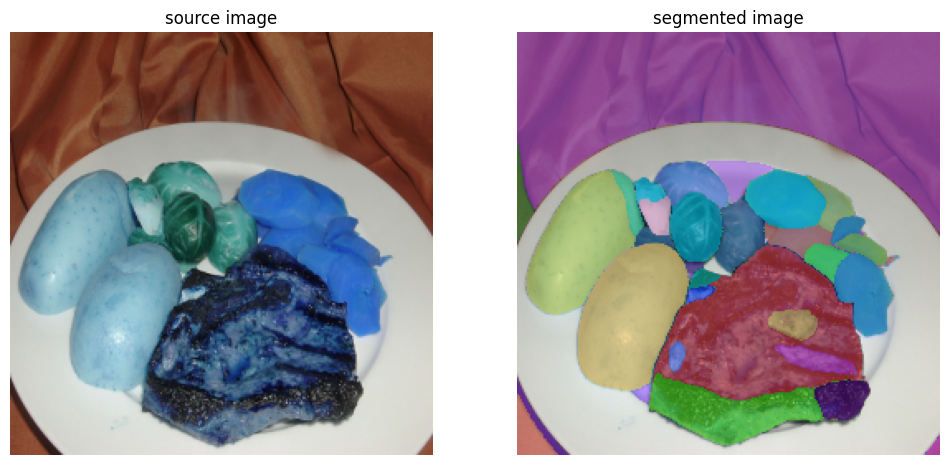

In [6]:
sam_model.preview_image_segmentation(image_rgb.copy(), merge_similar=True)

In [7]:
sam_segmentation_masks = sam_model.generate_masks(image_rgb, merge_similar=True)

In [8]:
sam_masks = [
    mask['segmentation']
    for mask
    in sorted(sam_segmentation_masks, key=lambda x: x['area'], reverse=True)
]

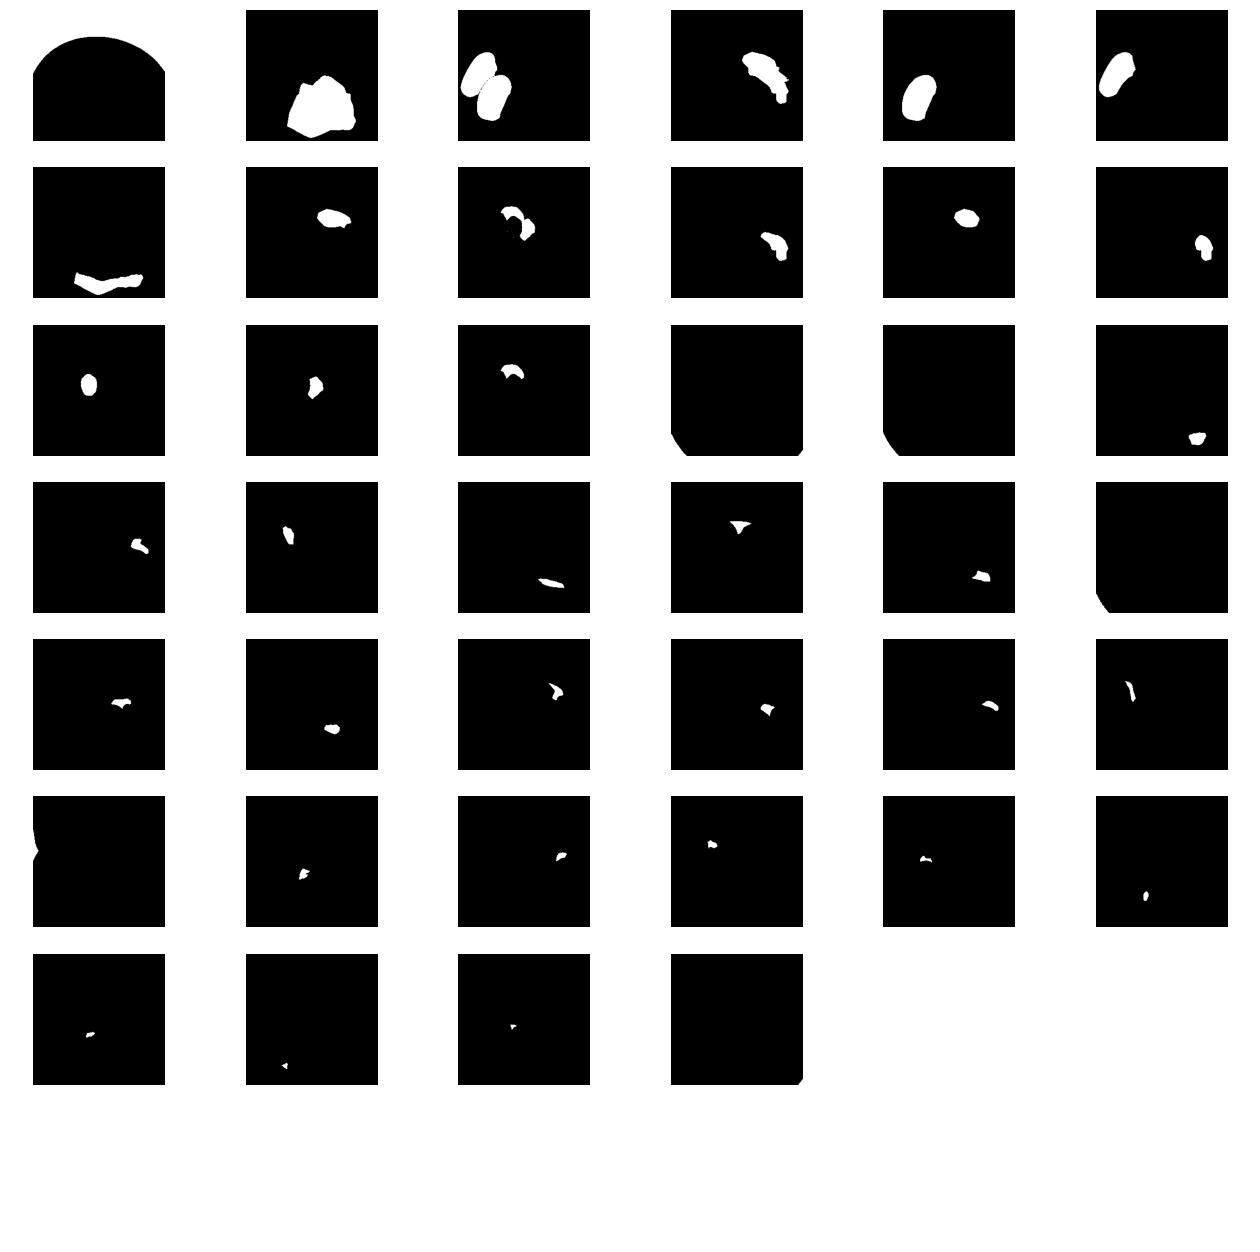

In [9]:
sv.plot_images_grid(
    images=sam_masks,
    grid_size=(8, int(len(sam_masks)//8+1)),
    size=(16, 16)
)

### B3 SegFormer
---

In [10]:
from src.b3_seg_former_model import SegFormerModel

In [11]:
segformer_model = SegFormerModel()

In [12]:
segformer_mask = segformer_model.predict_segmentation_mask(image_rgb)

(256, 256, 3) (256, 256, 3)


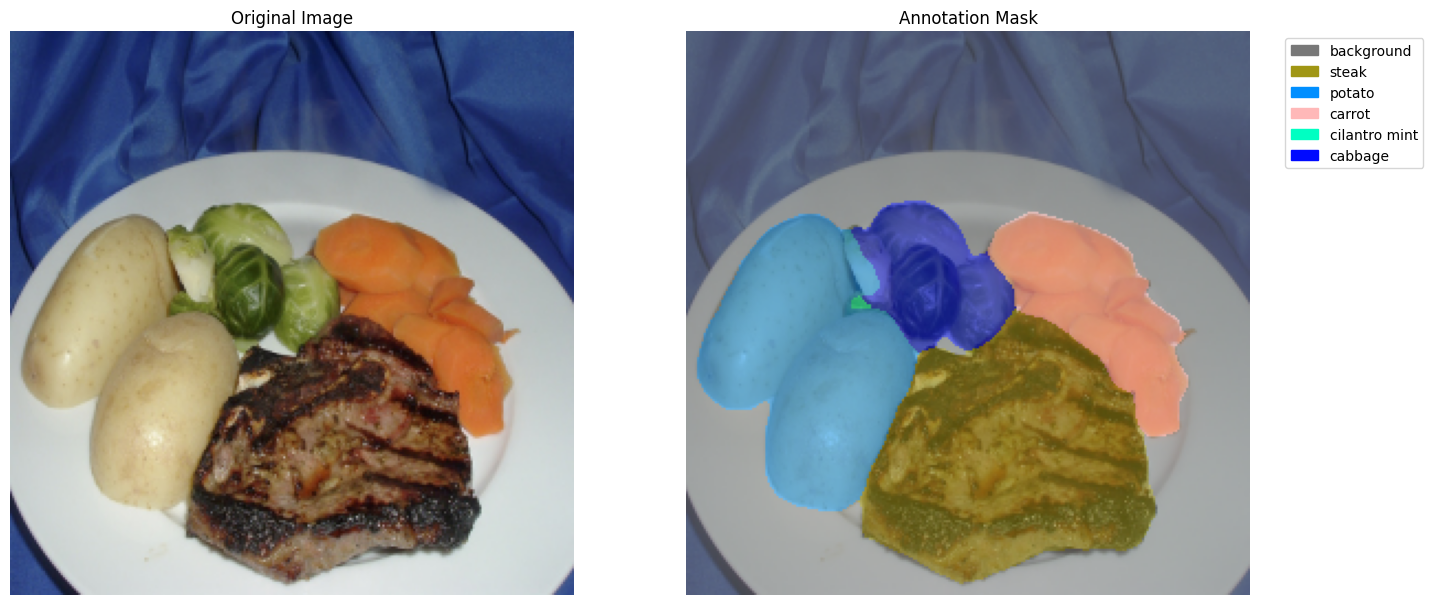

In [13]:
segformer_model.preview_image_segmentation(image_rgb)

### Merge masks
---

In [14]:
base_mask = np.zeros_like(segformer_mask)

In [15]:
for sam_segmentation_mask in sam_masks:
    sam_segmentation_mask = np.copy(sam_segmentation_mask).astype(bool)
    image_target_region = segformer_mask[sam_segmentation_mask]
    class_ids, counts = np.unique(image_target_region, return_counts=True)
    dominant_class = class_ids[np.argmax(counts)]
    base_mask[sam_segmentation_mask] = dominant_class

In [16]:
color_seg = segformer_model.generate_pallete_for_mask(base_mask)
blend = segformer_model.apply_mask_on_image(image_rgb, color_seg)

(256, 256, 3) (256, 256, 3)


In [17]:
from src.constants.category_id import PALLETE, CATEGORY_ID

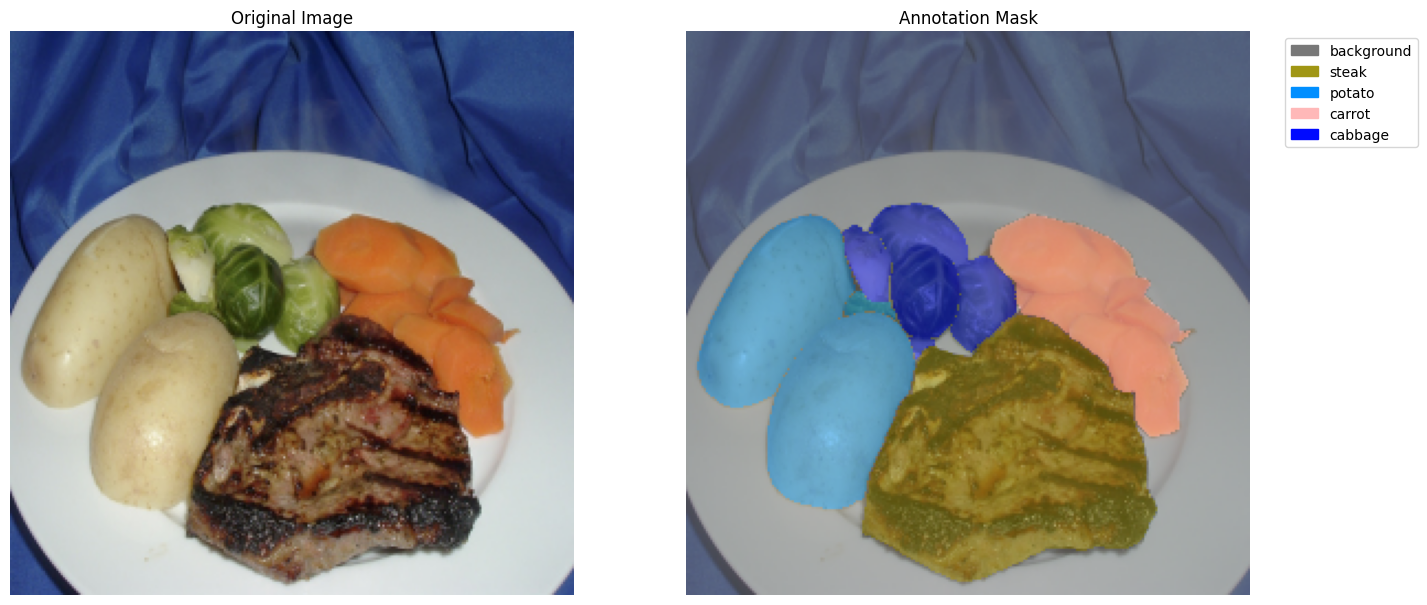

In [18]:
fig, axs = plt.subplots(1, 2, figsize=(16, 12))
axs[0].set_title('Original Image')
axs[1].set_title('Annotation Mask')
axs[0].axis('off')
axs[1].axis('off')
axs[0].imshow(image_rgb)
axs[1].imshow(blend)
unique_labels = np.unique(base_mask)
patches = [
    mpatches.Patch(
        color=np.array(PALLETE[label])/255,
        label=CATEGORY_ID.get(label, f'Class {label}')
    )
    for label in unique_labels if label in CATEGORY_ID]
axs[1].legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left')

## References

[1] https://blog.roboflow.com/how-to-use-segment-anything-model-sam/